In [2]:
from utilities import init_bigquery_client
from google.cloud import bigquery
import os
import pandas as pd
import numpy as np
import plotly.express as px

#init BigQuery client
bq = init_bigquery_client()

Using BigQuery credentials: etl-testing-478716-c0b6c2c512e0.json


In [3]:
# Read from the 'users' table in BigQuery
query = """
    SELECT *
    FROM `etl-testing-478716.posthog_aggregated_prod.sessions_aggregated`
"""
sessions_agg_df = bq.query(query).to_dataframe()

/opt/miniconda3/envs/heyyall/lib/python3.13/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [23]:
sessions_agg_df[sessions_agg_df['viewed_event'] == True].session_duration.describe()

count    1540.000000
mean      256.755195
std       685.437730
min         0.000000
25%         6.000000
50%        18.000000
75%       134.000000
max      7638.000000
Name: session_duration, dtype: float64

In [25]:
sessions_agg_df[sessions_agg_df['joined_event'] == True].session_duration.describe()

count      62.000000
mean      561.758065
std       790.344928
min         9.000000
25%        67.750000
50%       252.500000
75%       719.250000
max      4266.000000
Name: session_duration, dtype: float64

In [7]:
from plotnine import *

In [17]:
duration_plot = (ggplot(sessions_agg_df, aes(x='session_duration')) +
 geom_histogram(binwidth = 700) +
 labs(title='Distribution of Session Durations',
      x='Session Duration (seconds)',
      y='Frequency') +
 theme_minimal())

/opt/miniconda3/envs/heyyall/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_bin : Removed 13 rows containing non-finite values.


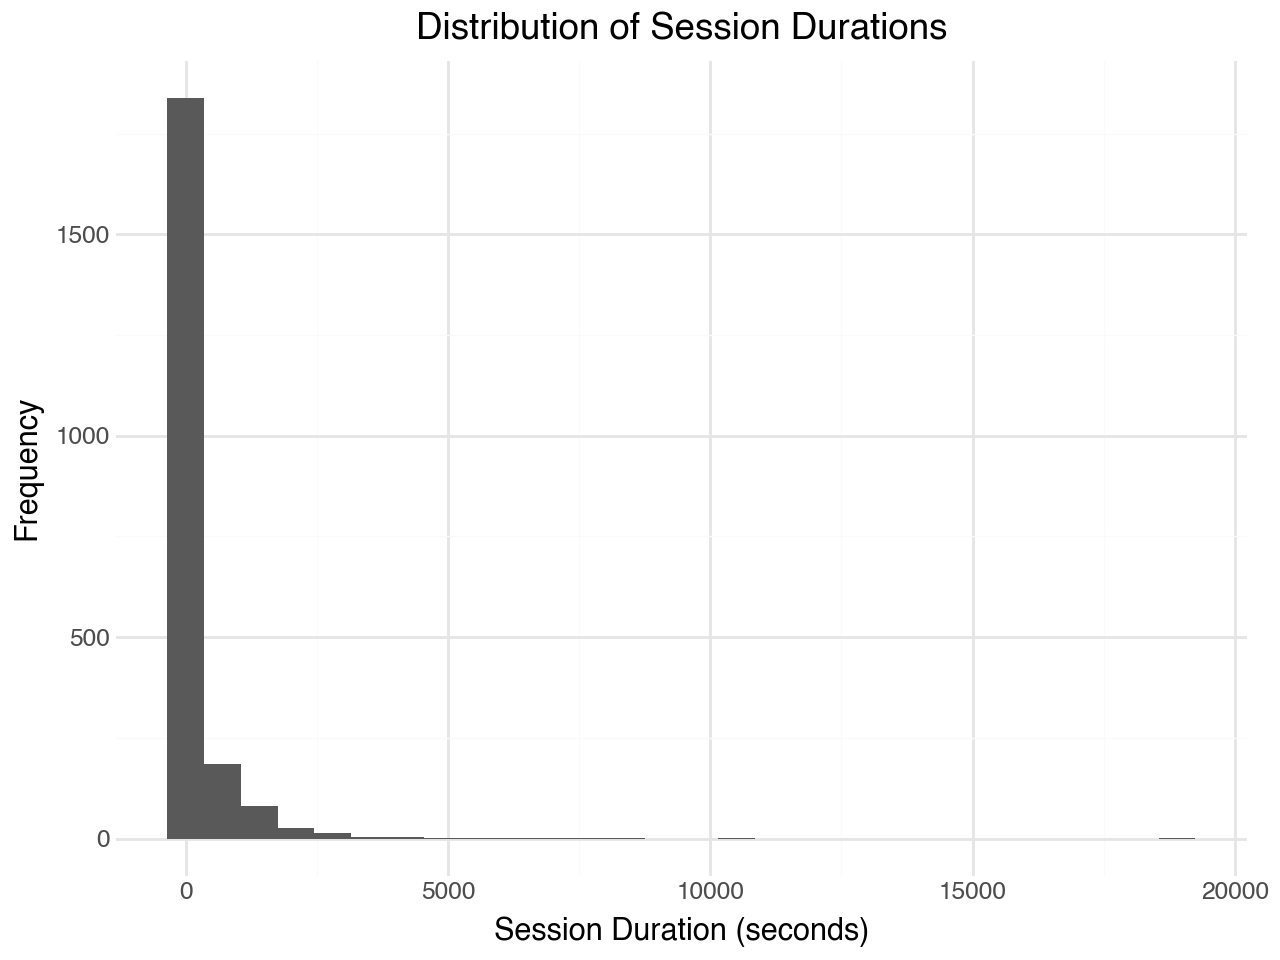

In [18]:
duration_plot.show()